## Imports e configurações

In [ ]:
import pandas as pd
import psycopg2
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


load_dotenv("../.env")

DB_CONFIG = {
    'host': os.getenv('POSTGRES_HOST'),
    'port': int(os.getenv('POSTGRES_PORT')),
    'database': os.getenv('POSTGRES_DB'),
    'user': os.getenv('POSTGRES_USER'),
    'password': os.getenv('POSTGRES_PASSWORD')
}


5433


## Carregamento dos dados

In [2]:
QUERY = "SELECT * FROM silver.fifa21_players;"


plt.style.use('seaborn-v0_8')
sns.set_theme(context="notebook", style="whitegrid")

conn = psycopg2.connect(**DB_CONFIG)

df = pd.read_sql(QUERY, conn)

conn.close()

df.head()

/tmp/ipykernel_52079/2403009786.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(QUERY, conn)


,player_id,long_name,name,nationality,positions,age,overall_rating,potential_rating,team,contract_period,...,defense_work_rate,international_reputation,pace,shooting,passing,dribbling_stat,defending_stat,physical,hits,created_at
0,158023,Lionel Messi,L. Messi,Argentina,RW ST CF,33,93,93,FC Barcelona,2004 ~ 2021,...,Low,5,85,92,91,95,38,65,372,2026-01-19 14:01:33.548775
1,20801,C. Ronaldo dos Santos Aveiro,Cristiano Ronaldo,Portugal,ST LW,35,92,92,Juventus,2018 ~ 2022,...,Low,5,89,93,81,89,35,77,344,2026-01-19 14:01:33.548775
2,200389,Jan Oblak,J. Oblak,Slovenia,GK,27,91,93,Atlético Madrid,2014 ~ 2023,...,Medium,3,87,92,78,90,52,90,86,2026-01-19 14:01:33.548775
3,192985,Kevin De Bruyne,K. De Bruyne,Belgium,CAM CM,29,91,91,Manchester City,2015 ~ 2023,...,High,4,76,86,93,88,64,78,163,2026-01-19 14:01:33.548775
4,190871,Neymar da Silva Santos Jr.,Neymar Jr,Brazil,LW CAM,28,91,91,Paris Saint-Germain,2017 ~ 2022,...,Medium,5,91,85,86,94,36,59,273,2026-01-19 14:01:33.548775


## Valor de Mercado vs Overall (Custo-Benefício)

O gráfico mostra uma relação positiva entre o overall dos jogadores e seu valor de mercado: atletas com melhor desempenho técnico tendem a valer mais. No entanto, essa relação não é linear, havendo grande variação de preços para jogadores com o mesmo overall.
Observa-se que fatores como idade, potencial, clube e visibilidade no mercado influenciam fortemente o valor, explicando casos de jogadores supervalorizados (alto valor, overall mediano) e subvalorizados (bom overall com baixo custo).
O gráfico é útil para identificar oportunidades de custo-benefício, auxiliando decisões de scouting, compra, venda ou renovação de contratos.

In [3]:
fig = px.scatter(
    df,
    x='value_eur',
    y='overall_rating',
    log_x=True,
    hover_name='name',
    hover_data={
        'value_eur': ':,.0f',
        'overall_rating': True,
        'age': True,
        'nationality': True,
        'team': True
    },
    title='Custo-benefício: Valor de Mercado vs Overall'
)

fig.update_xaxes(
    tickvals=[
        100_000,
        250_000,
        500_000,
        1_000_000,
        5_000_000,
        10_000_000,
        50_000_000,
        100_000_000
    ],
    ticktext=[
        '€100k',
        '€250k',
        '€500k',
        '€1M',
        '€5M',
        '€10M',
        '€50M',
        '€100M'
    ],
    title='Valor de Mercado (€)'
)

fig.update_layout(
    yaxis_title='Overall',
    template='plotly_white'
)

fig.show()

## Distribuição de Overall x Idade dos Jogadores
O gráfico evidencia que o overall dos jogadores tende a crescer até a fase adulta (pico geralmente entre 25 e 30 anos) e declinar gradualmente com o avanço da idade. Jogadores muito jovens apresentam maior dispersão de overall, refletindo estágios distintos de desenvolvimento.
A presença de atletas mais velhos com overall elevado indica experiência e consistência, enquanto jovens com overall alto representam talentos promissores. Esse gráfico é útil para apoiar decisões de planejamento de elenco, equilibrando jogadores em pico de desempenho com apostas de longo prazo.

In [4]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["best_overall_rating"] = pd.to_numeric(df["best_overall_rating"], errors="coerce")

fig = px.scatter(
    df,
    x="age",
    y="best_overall_rating",
    hover_name="name",
    hover_data={
        "age": True,
        "best_overall_rating": True,
        "positions": True,
        "team": True
    },
    opacity=0.6,
    title="Relação entre Idade e Overall dos Jogadores"
)

fig.update_traces(marker=dict(size=6))

fig.update_layout(
    xaxis_title="Idade",
    yaxis_title="Overall",
    template="plotly_white"
)

fig.show()

## Potencial de Crescimento
O gráfico destaca os 20 jogadores com maior diferença entre potencial (POT) e overall atual (OVA), indicando aqueles com maior margem de evolução ao longo da carreira. Quanto maior a barra, maior a expectativa de crescimento do jogador.

Esses atletas representam oportunidades estratégicas, especialmente para clubes que buscam investimentos de longo prazo, desenvolvimento interno ou futura valorização de mercado. Em geral, são jogadores jovens ou em início de carreira, cujo desempenho ainda não atingiu seu teto máximo.

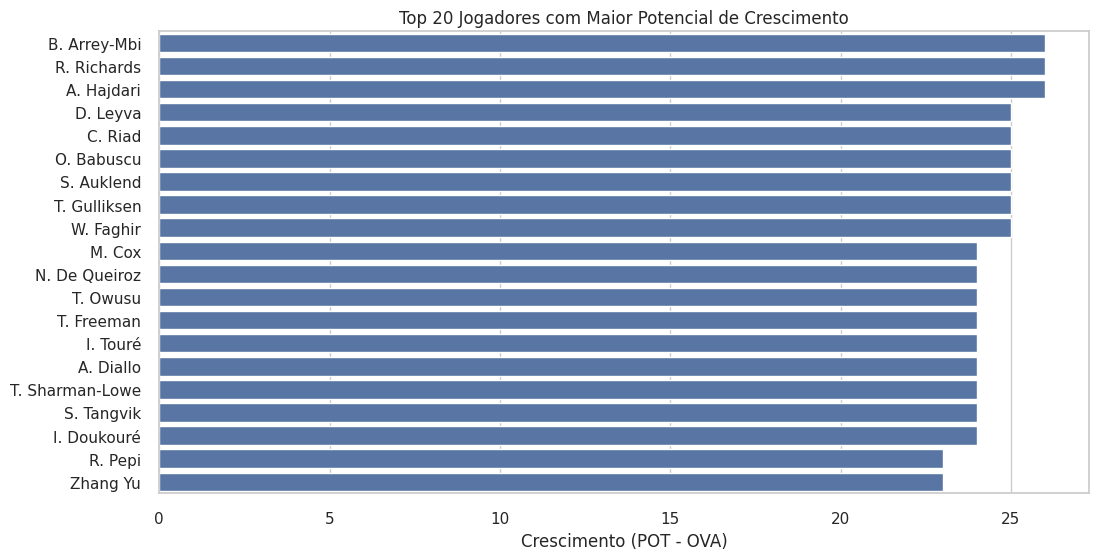

In [5]:
df['growth'] = df['potential_rating'] - df['overall_rating']
top_growth = df.sort_values('growth', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_growth,
    x='growth',
    y='name'
)

plt.title('Top 20 Jogadores com Maior Potencial de Crescimento')
plt.xlabel('Crescimento (POT - OVA)')
plt.ylabel('')
plt.show()


## Distribuição de Posições dos Jogadores
O mercado é fortemente abastecido por jogadores de posições centrais, enquanto posições mais específicas especialmente laterais e goleiros
Esse gráfico permite identificar onde há maior oferta de atletas no jogo.

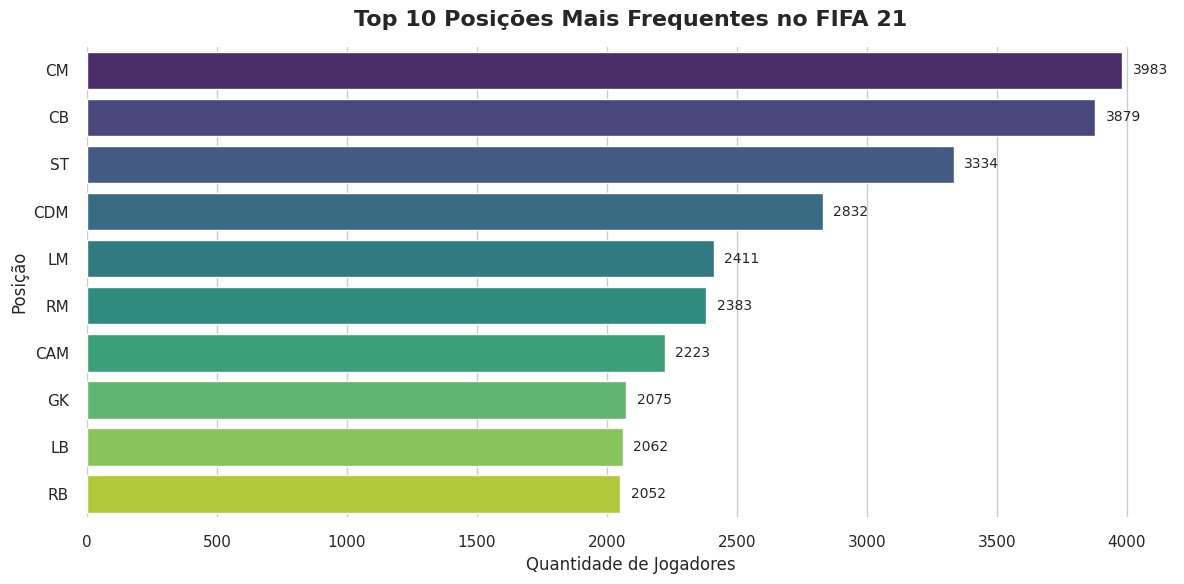

In [6]:
positions = (
    df["positions"]
    .dropna()
    .str.split(" ")
    .explode()
)

sns.set_theme(style="whitegrid", context="notebook")

top_positions = positions.value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))

bars = sns.barplot(
    x=top_positions.values,
    y=top_positions.index,
    hue=top_positions.index,  
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 10 Posições Mais Frequentes no FIFA 21",
    fontsize=16,
    weight="bold",
    pad=15
)
ax.set_xlabel("Quantidade de Jogadores", fontsize=12)
ax.set_ylabel("Posição", fontsize=12)

sns.despine(left=True, bottom=True)

for i, value in enumerate(top_positions.values):
    ax.text(
        value + (top_positions.values.max() * 0.01),
        i,
        f"{value}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Overall Médio por Time

O gráfico apresenta os 10 times com maior overall médio, considerando apenas equipes com no mínimo 10 jogadores.
Os resultados mostram que esses times concentram elencos mais qualificados de forma consistente, não dependendo apenas de estrelas isoladas. Um overall médio elevado indica nível técnico homogêneo, refletindo maior competitividade.
Times com overall médio mais alto tendem a ser mais fortes coletivamente, oferecendo melhor desempenho geral

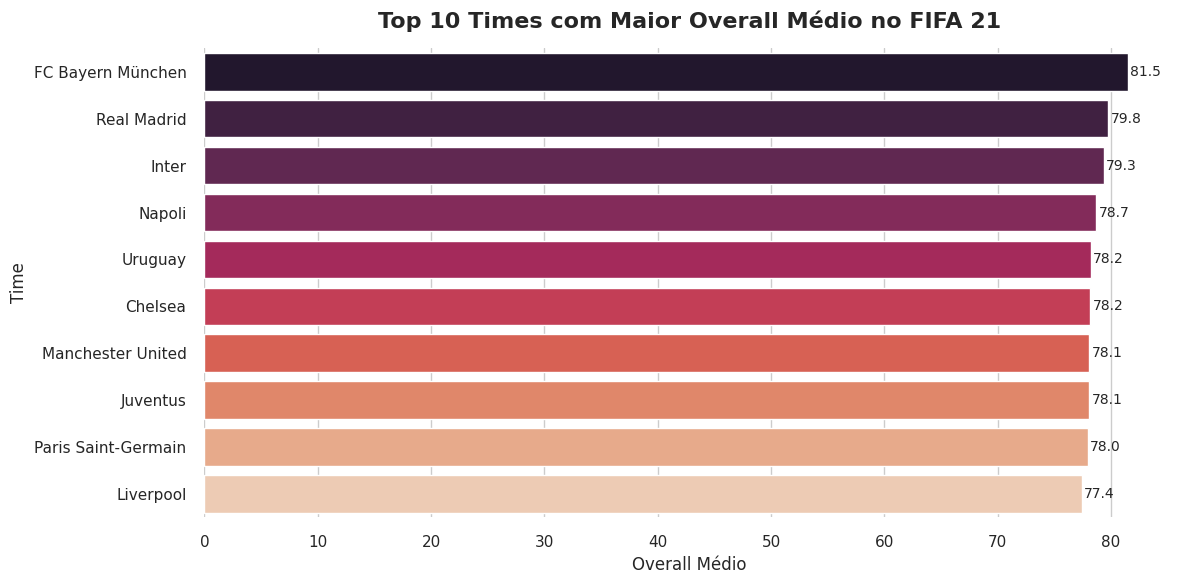

In [7]:
sns.set_theme(style="whitegrid", context="notebook")

team_overall = (
    df
    .dropna(subset=["team", "overall_rating"])
    .groupby("team", as_index=False)
    .agg(
        overall_medio=("overall_rating", "mean"),
        qtd_jogadores=("overall_rating", "count")
    )
)

team_overall = team_overall[team_overall["qtd_jogadores"] >= 10]

top_teams_overall = team_overall.sort_values(
    "overall_medio", ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    x="overall_medio",
    y="team",
    hue="team",     
    data=top_teams_overall,
    palette="rocket",
    legend=False,      
    ax=ax
)

ax.set_title(
    "Top 10 Times com Maior Overall Médio no FIFA 21",
    fontsize=16,
    weight="bold",
    pad=15
)
ax.set_xlabel("Overall Médio", fontsize=12)
ax.set_ylabel("Time", fontsize=12)

for i, value in enumerate(top_teams_overall["overall_medio"]):
    ax.text(
        value + 0.2,
        i,
        f"{value:.1f}",
        va="center",
        fontsize=10
    )

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Perfil Físico Médio dos Jogadores

O gráfico compara a altura média e o peso médio dos jogadores do FIFA 21, oferecendo uma visão geral do perfil físico padrão presente na base de dados.
Os valores indicam um equilíbrio físico típico do futebol profissional, servindo como referência para análises comparativas, como diferenças entre posições, ligas ou estilos de jogo.
A análise ajuda a entender o biotipo médio dos jogadores, sendo útil para relacionar características físicas com desempenho, função em campo ou perfil tático

In [8]:
df["height_cm"] = pd.to_numeric(df["height_cm"], errors="coerce")
df["weight_kg"] = pd.to_numeric(df["weight_kg"], errors="coerce")

avg_height = df["height_cm"].mean()
avg_weight = df["weight_kg"].mean()


In [9]:
physical_avg = pd.DataFrame({
    "Métrica": ["Altura Média (cm)", "Peso Médio (kg)"],
    "Valor": [avg_height, avg_weight]
})

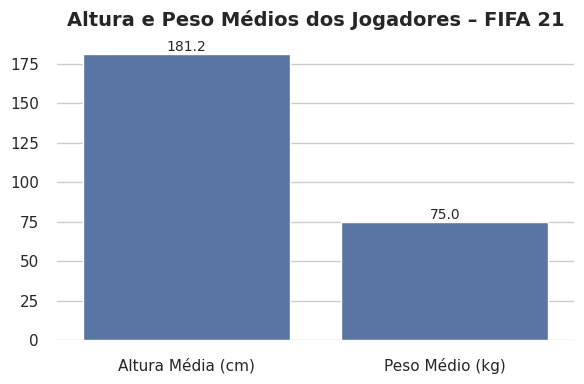

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=physical_avg,
    x="Métrica",
    y="Valor",
    ax=ax
)

ax.set_title(
    "Altura e Peso Médios dos Jogadores – FIFA 21",
    fontsize=14,
    weight="bold",
    pad=10
)

ax.set_ylabel("")
ax.set_xlabel("")

for i, value in enumerate(physical_avg["Valor"]):
    ax.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Valor Médio de Mercado por Idade

O gráfico mostra como o valor médio de mercado dos jogadores varia com a idade. Observa-se um crescimento progressivo do valor nas idades mais jovens, atingindo um pico na fase de auge físico e técnico, seguido por uma queda gradual conforme a idade avança.
O mercado valoriza jogadores em idade produtiva, combinando potencial, desempenho atual e longevidade.

In [11]:

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["value_eur"] = pd.to_numeric(df["value_eur"], errors="coerce")

df_age_value = df.dropna(subset=["age", "value_eur"])

In [12]:
df_age_value = (
    df
    .dropna(subset=["age", "value_eur"])
    .groupby("age", as_index=False)
    .agg(valor_medio=("value_eur", "mean"))
)

fig = px.line(
    df_age_value,
    x="age",
    y="valor_medio",
    markers=True,
    title="Valor Médio de Mercado por Idade – FIFA 21"
)

fig.update_yaxes(
    tickvals=[1e5, 5e5, 1e6, 5e6, 1e7, 5e7],
    ticktext=["€100k", "€500k", "€1M", "€5M", "€10M", "€50M"],
    title="Valor Médio (€)"
)

fig.update_layout(
    xaxis_title="Idade",
    template="plotly_white"
)

fig.show()

## Top 10 Times com Maior Tempo Médio de Contrato

O gráfico apresenta os 10 times com maior tempo médio de contrato, destaca quais clubes adotam uma estratégia de longo prazo, mantendo seus atletas vinculados por mais tempo. Contratos médios mais longos costumam indicar planejamento, estabilidade de elenco e proteção de ativos.
Times com maior tempo médio de contrato tendem a investir em continuidade e segurança contratual, enquanto equipes com contratos mais curtos podem estar focadas em renovações frequentes, vendas estratégicas ou elencos mais rotativos.

In [13]:
df_contract = df.dropna(subset=["team", "contract_period"]).copy()

df_contract[["contract_start", "contract_end"]] = (
    df_contract["contract_period"]
    .str.split("~", expand=True)
)

df_contract["contract_start"] = pd.to_numeric(
    df_contract["contract_start"].str.strip(),
    errors="coerce"
)

df_contract["contract_end"] = pd.to_numeric(
    df_contract["contract_end"].str.strip(),
    errors="coerce"
)

df_contract["contract_duration"] = (
    df_contract["contract_end"] - df_contract["contract_start"]
)

df_contract = df_contract[df_contract["contract_duration"] > 0]


In [14]:
team_contract_avg = (
    df_contract
    .groupby("team", as_index=False)
    .agg(
        tempo_medio_contrato=("contract_duration", "mean"),
        qtd_jogadores=("contract_duration", "count")
    )
)

# Filtrar times com amostra mínima
team_contract_avg = team_contract_avg[
    team_contract_avg["qtd_jogadores"] >= 10
]

top_10_contracts = (
    team_contract_avg
    .sort_values("tempo_medio_contrato", ascending=False)
    .head(10)
)


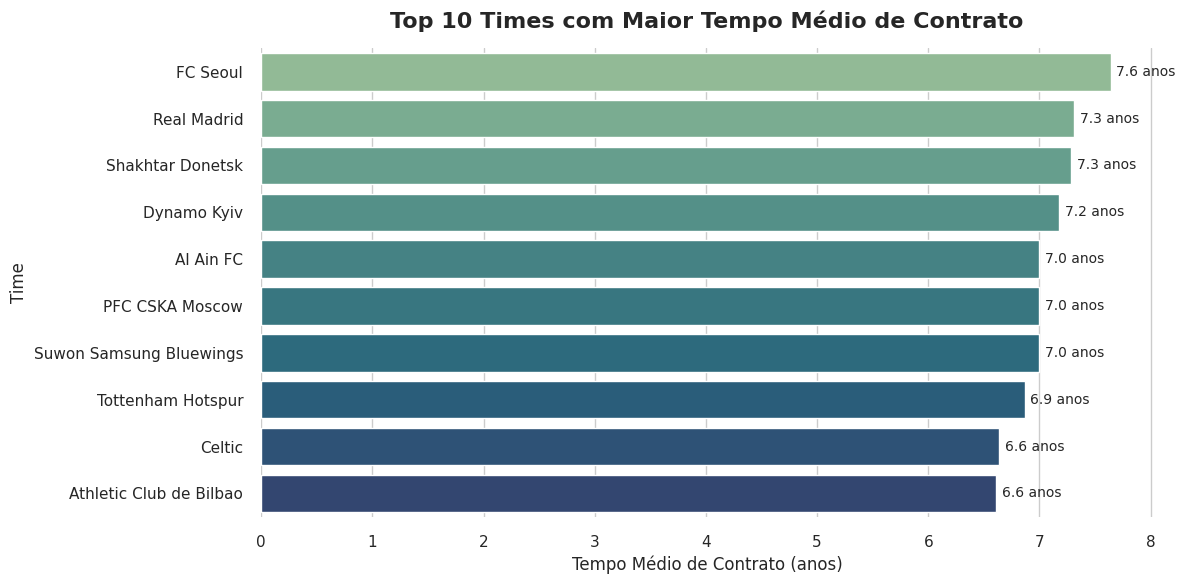

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_10_contracts,
    x="tempo_medio_contrato",
    y="team",
    hue="team",
    palette="crest",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 10 Times com Maior Tempo Médio de Contrato",
    fontsize=16,
    weight="bold",
    pad=15
)
ax.set_xlabel("Tempo Médio de Contrato (anos)", fontsize=12)
ax.set_ylabel("Time", fontsize=12)

for i, value in enumerate(top_10_contracts["tempo_medio_contrato"]):
    ax.text(
        value + 0.05,
        i,
        f"{value:.1f} anos",
        va="center",
        fontsize=10
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Top 10 Times com Maiores Gastos com Salários

Este gráfico mostra os 10 times com maiores gastos totais em salários. Ele evidencia quais clubes concentram maior investimento financeiro em folha salarial, geralmente associado a elencos mais qualificados, presença de jogadores estrelas e maior competitividade. 

Altos gastos salariais indicam poder financeiro e estratégia de retenção de talentos.

In [16]:
df_wages = (
    df
    .dropna(subset=["team", "wage_eur"])
    .groupby("team", as_index=False)
    .agg(
        gasto_total_salarios=("wage_eur", "sum"),
        qtd_jogadores=("wage_eur", "count")
    )
)

# Considerar apenas times com elenco mínimo
df_wages = df_wages[df_wages["qtd_jogadores"] >= 10]

top_10_wages = (
    df_wages
    .sort_values("gasto_total_salarios", ascending=False)
    .head(10)
)


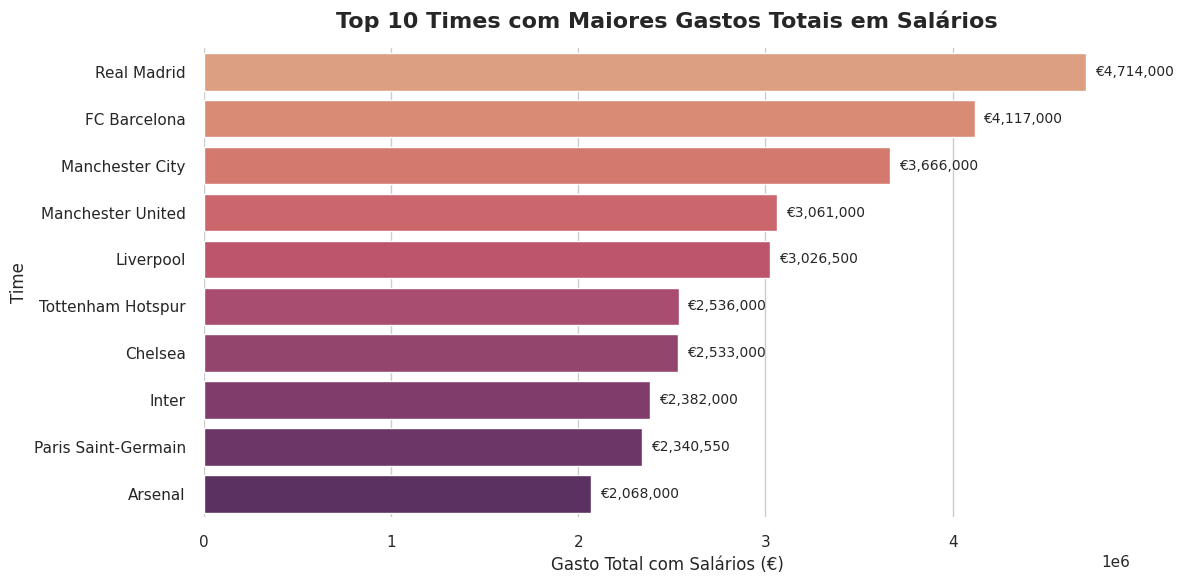

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_10_wages,
    x="gasto_total_salarios",
    y="team",
    hue="team",
    palette="flare",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 10 Times com Maiores Gastos Totais em Salários",
    fontsize=16,
    weight="bold",
    pad=15
)
ax.set_xlabel("Gasto Total com Salários (€)", fontsize=12)
ax.set_ylabel("Time", fontsize=12)

for i, value in enumerate(top_10_wages["gasto_total_salarios"]):
    ax.text(
        value + (top_10_wages["gasto_total_salarios"].max() * 0.01),
        i,
        f"€{value:,.0f}",
        va="center",
        fontsize=10
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## Top 10 Jogadores com Maior Dribbling

Este gráfico apresenta os 10 jogadores com os maiores valores do atributo Dribbling, destacando os atletas mais habilidosos no controle de bola, mudanças rápidas de direção e capacidade de superar adversários no mano a mano. Os jogadores no topo do ranking são, em geral, atacantes ou meias ofensivos, posições onde o drible é um diferencial estratégico para criar jogadas. 
Um alto valor de dribbling indica jogadores ideais para estilos de jogo mais ofensivos e técnicos, sendo especialmente valiosos em equipes que priorizam posse de bola.

In [18]:
df_dribbling = (
    df
    .dropna(subset=["name", "dribbling"])
    .sort_values("dribbling", ascending=False)
    .head(10)
)


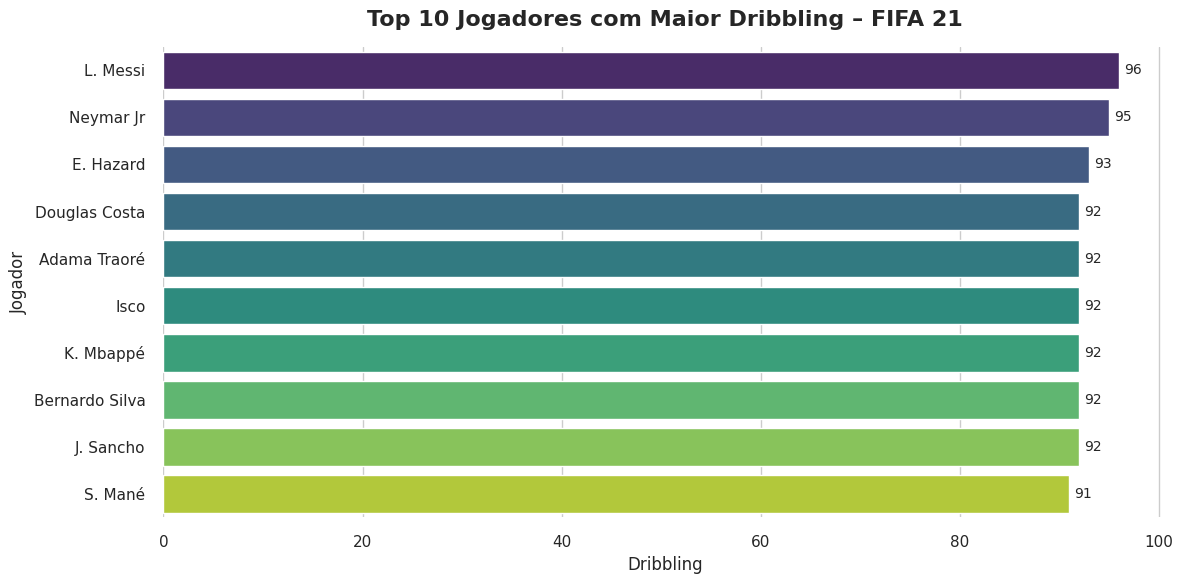

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_dribbling,
    x="dribbling",
    y="name",
    hue="name",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 10 Jogadores com Maior Dribbling – FIFA 21",
    fontsize=16,
    weight="bold",
    pad=15
)
ax.set_xlabel("Dribbling", fontsize=12)
ax.set_ylabel("Jogador", fontsize=12)

for i, value in enumerate(df_dribbling["dribbling"]):
    ax.text(
        value + 0.5,
        i,
        f"{int(value)}",
        va="center",
        fontsize=10
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Distribuição do Valor de Mercado por Macro-Posição

O gráfico mostra que atacantes e meio-campistas concentram os maiores valores de mercado, com grande variação entre jogadores. Defensores têm valores mais equilibrados, enquanto goleiros apresentam os menores e mais estáveis preços.

In [20]:
def map_position(pos):
    if "GK" in pos:
        return "Goleiro"
    elif any(p in pos for p in ["CB", "RB", "LB", "RWB", "LWB"]):
        return "Defesa"
    elif any(p in pos for p in ["CM", "CDM", "CAM"]):
        return "Meio-campo"
    else:
        return "Ataque"

df["position_group"] = df["positions"].apply(map_position)


In [21]:
fig = px.box(
    df,
    x="position_group",
    y="value_eur",
    points="all",
    log_y=True,
    title="Distribuição do Valor de Mercado por Macro-Posição",
    hover_data={
        "name": True,
        "overall_rating": True,
        "age": True,
        "team": True
    },
    labels={
        "position_group": "Posição",
        "value_eur": "Valor de Mercado (€)"
    }
)

fig.update_traces(jitter=0.3)
fig.update_layout(template="plotly_white")

fig.show()